<a href="https://colab.research.google.com/github/Alexa0723/Estructuras-BD/blob/main/Lab_Quadtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import random
import time
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import unittest
import statistics
import matplotlib.ticker as ticker

**GENERAR DATOS**


In [76]:
random.seed(42)
CITY_W = 10000  # metros
CITY_H = 10000

puntos = [(random.uniform(0, CITY_W), random.uniform(0, CITY_H))
          for _ in range(10000)]

**QUADTREE**

In [77]:
MAX_PUNTOS = 8  # si hay más, subdividimos

class NodoQuadtree:
    def __init__(self, x, y, ancho, alto):
        # x, y = esquina superior izquierda
        self.x = x
        self.y = y
        self.ancho = ancho
        self.alto = alto
        self.pts = []       # puntos en este nodo (solo si es hoja)
        self.hijos = None   # lista de 4 hijos si está subdividido

    def es_hoja(self):
        return self.hijos is None

    def contiene(self, punto):
        px, py = punto
        return (self.x <= px < self.x + self.ancho and
                self.y <= py < self.y + self.alto)

    def insertar(self, punto):
        # Si el punto no cabe en este nodo, ignorar
        if not self.contiene(punto):
            return False

        # Si soy hoja y tengo espacio, guardo el punto
        if self.es_hoja():
            self.pts.append(punto)
            # Si supero el límite, subdivido
            if len(self.pts) > MAX_PUNTOS and self.ancho > 10:
                self.subdividir()
            return True

        # Si ya tengo hijos, inserto en el hijo que corresponde
        for hijo in self.hijos:
            if hijo.insertar(punto):
                return True
        return False

    def subdividir(self):
        mx = self.ancho / 2
        my = self.alto / 2

        self.hijos = [
            NodoQuadtree(self.x,      self.y,      mx, my),  # superior izq
            NodoQuadtree(self.x + mx, self.y,      mx, my),  # superior der
            NodoQuadtree(self.x,      self.y + my, mx, my),  # inferior izq
            NodoQuadtree(self.x + mx, self.y + my, mx, my),  # inferior der
        ]

        # Redistribuir los puntos que tenía este nodo
        for p in self.pts:
            for hijo in self.hijos:
                if hijo.insertar(p):
                    break
        self.pts = []  # ya no soy hoja, borro mis puntos

    def intersecta_circulo(self, cx, cy, radio):
        #¿El rectángulo de este nodo intersecta con el círculo?
        # Punto más cercano del rectángulo al centro del círculo
        cerca_x = max(self.x, min(cx, self.x + self.ancho))
        cerca_y = max(self.y, min(cy, self.y + self.alto))
        dx = cx - cerca_x
        dy = cy - cerca_y
        return dx*dx + dy*dy <= radio*radio

    def contar_puntos(self):
        if self.es_hoja():
            return len(self.pts)
        return sum(h.contar_puntos() for h in self.hijos)

    def max_pts_hoja(self):
        if self.es_hoja():
            return len(self.pts)
        return max(h.max_pts_hoja() for h in self.hijos)

# CONSTRUCCIÓN DEL ÁRBOL

print("Construyendo Quadtree con 10.000 puntos")
t0 = time.time()

arbol = NodoQuadtree(0, 0, CITY_W, CITY_H)
for p in puntos:
    arbol.insertar(p)

t_construccion = time.time() - t0
print(f"  Tiempo de construcción: {t_construccion*1000:.2f} ms")


# 4. BÚSQUEDA POR RADIO (Range Search)
def busqueda_radio_qt(nodo, cx, cy, radio, resultado):
    # Si el nodo no intersecta con el círculo, ignorar
    if not nodo.intersecta_circulo(cx, cy, radio):
        return

    if nodo.es_hoja():
        # Revisar cada punto del nodo
        for p in nodo.pts:
            dx = p[0] - cx
            dy = p[1] - cy
            if dx*dx + dy*dy <= radio*radio:
                resultado.append(p)
    else:
        for hijo in nodo.hijos:
            busqueda_radio_qt(hijo, cx, cy, radio, resultado)


def busqueda_radio_fuerza_bruta(puntos, cx, cy, radio):
    """Búsqueda por radio revisando TODOS los puntos."""
    resultado = []
    r2 = radio * radio
    for p in puntos:
        dx = p[0] - cx
        dy = p[1] - cy
        if dx*dx + dy*dy <= r2:
            resultado.append(p)
    return resultado

Construyendo Quadtree con 10.000 puntos
  Tiempo de construcción: 103.59 ms


**VECINO MÁS CERCANO**

In [78]:
def knn_qt(nodo, cx, cy, k, heap):

    if nodo.es_hoja():
        for p in nodo.pts:
            dx = p[0] - cx
            dy = p[1] - cy
            d2 = dx*dx + dy*dy

            if len(heap) < k:
                heap.append((d2, p))
                heap.sort(key=lambda x: x[0], reverse=True)  # peor al frente
            elif d2 < heap[0][0]:
                heap[0] = (d2, p)
                heap.sort(key=lambda x: x[0], reverse=True)
        return

    # Ordenar hijos por distancia al query (explorar más prometedores primero)
    def dist_nodo(n):
        ncx = n.x + n.ancho / 2
        ncy = n.y + n.alto / 2
        return (cx - ncx)**2 + (cy - ncy)**2

    hijos_ord = sorted(nodo.hijos, key=dist_nodo)

    for hijo in hijos_ord:
        # Distancia mínima del rectángulo al punto query
        cerca_x = max(hijo.x, min(cx, hijo.x + hijo.ancho))
        cerca_y = max(hijo.y, min(cy, hijo.y + hijo.alto))
        dx = cx - cerca_x
        dy = cy - cerca_y
        dist_min2 = dx*dx + dy*dy

        # Si el peor del heap es menor que la distancia mínima al hijo,
        # no vale la pena explorar ese hijo
        peor = heap[0][0] if len(heap) == k else float('inf')
        if dist_min2 < peor:
            knn_qt(hijo, cx, cy, k, heap)


def knn_fuerza_bruta(puntos, cx, cy, k):
    """KNN revisando TODOS los puntos."""
    dists = []
    for p in puntos:
        dx = p[0] - cx
        dy = p[1] - cy
        dists.append((dx*dx + dy*dy, p))
    dists.sort(key=lambda x: x[0])
    return [(math.sqrt(d), p) for d, p in dists[:k]]

**PRUEBA Y COMPARACIÓN**

In [79]:
query_x, query_y = 5000, 5000  # centro
RADIO = 500  # metros
K = 5

print("\n" + "="*50)
print("BÚSQUEDA POR RADIO")
print("="*50)
print(f"Centro de consulta : ({query_x}, {query_y})")
print(f"Radio              : {RADIO} m\n")

t0 = time.time()
res_qt = []
busqueda_radio_qt(arbol, query_x, query_y, RADIO, res_qt)
t_qt = (time.time() - t0) * 1000

t0 = time.time()
res_bf = busqueda_radio_fuerza_bruta(puntos, query_x, query_y, RADIO)
t_bf = (time.time() - t0) * 1000


print("Resultados:")
print(f"  Quadtree     : {len(res_qt)} puntos | {t_qt:.3f} ms")
print(f"  Fuerza Bruta : {len(res_bf)} puntos | {t_bf:.3f} ms")
mejora_radio = t_bf / t_qt if t_qt > 0 else float('inf')
print(f"\nMejora (veces más rápido): {mejora_radio:.2f}x")


print("\n" + "="*50)
print("VECINOS MÁS CERCANOS (KNN)")
print("="*50)
print(f"k = {K}\n")

t0 = time.time()
heap_qt = []
knn_qt(arbol, query_x, query_y, K, heap_qt)
vecinos_qt = [(math.sqrt(d), p) for d, p in sorted(heap_qt, key=lambda x: x[0])]
t_qt_knn = (time.time() - t0) * 1000

t0 = time.time()
vecinos_bf = knn_fuerza_bruta(puntos, query_x, query_y, K)
t_bf_knn = (time.time() - t0) * 1000


print("Tiempos:")
print(f"  Quadtree     : {t_qt_knn:.3f} ms")
print(f"  Fuerza Bruta : {t_bf_knn:.3f} ms")
mejora_knn = t_bf_knn / t_qt_knn if t_qt_knn > 0 else float('inf')
print(f"\nMejora (veces más rápido): {mejora_knn:.2f}x")

print("\nVecinos encontrados (Quadtree):")
for i, (dist, p) in enumerate(vecinos_qt, 1):
    print(f"  {i}. ({p[0]:.1f}, {p[1]:.1f}) → {dist:.1f} m")

print("="*50)


BÚSQUEDA POR RADIO
Centro de consulta : (5000, 5000)
Radio              : 500 m

Resultados:
  Quadtree     : 69 puntos | 0.383 ms
  Fuerza Bruta : 69 puntos | 2.592 ms

Mejora (veces más rápido): 6.77x

VECINOS MÁS CERCANOS (KNN)
k = 5

Tiempos:
  Quadtree     : 0.514 ms
  Fuerza Bruta : 9.955 ms

Mejora (veces más rápido): 19.38x

Vecinos encontrados (Quadtree):
  1. (5031.5, 4997.3) → 31.6 m
  2. (5054.4, 4949.7) → 74.1 m
  3. (4906.3, 4995.8) → 93.8 m
  4. (5102.6, 5006.0) → 102.8 m
  5. (5128.2, 4972.8) → 131.0 m


**VISUALIZACIONES**

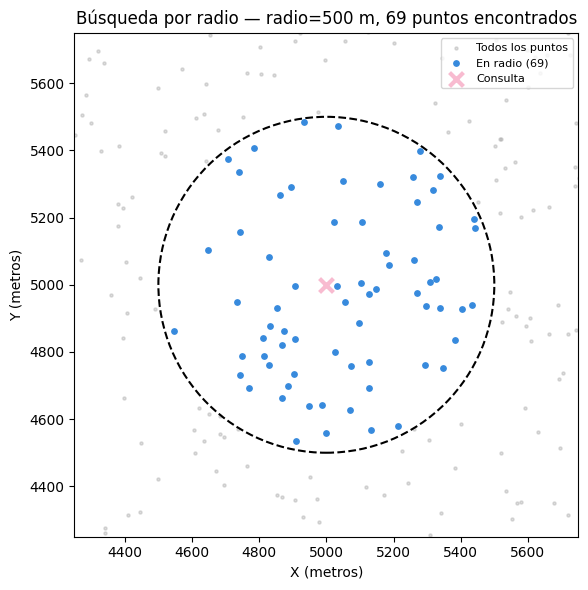

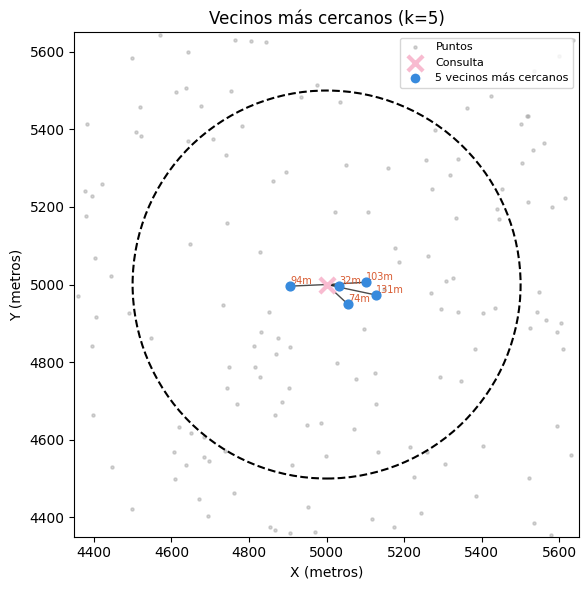

In [80]:
# VISUALIZACIÓN: puntos en radio
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f"Búsqueda por radio — radio={RADIO} m, {len(res_qt)} puntos encontrados")

# Puntos
xs = [p[0] for p in puntos]
ys = [p[1] for p in puntos]
ax.scatter(xs, ys, s=5, color='#aaaaaa', alpha=0.4, label='Todos los puntos')

# Puntos dentro del radio
if res_qt:
    rx = [p[0] for p in res_qt]
    ry = [p[1] for p in res_qt]
    ax.scatter(rx, ry, s=15, color='#378ADD', zorder=3,
               label=f'En radio ({len(res_qt)})')

# Círculo
circulo = plt.Circle((query_x, query_y), RADIO,
                     color='#000000', fill=False,
                     linewidth=1.5, linestyle='--', zorder=4)
ax.add_patch(circulo)

# Consulta
ax.scatter([query_x], [query_y],
           s=100, color='#F8BBD0',
           marker='x', linewidths=3,
           zorder=5, label='Consulta')

# ZOOM
margen = RADIO * 1.5
ax.set_xlim(query_x - margen, query_x + margen)
ax.set_ylim(query_y - margen, query_y + margen)

# Leyenda
handles, labels = ax.get_legend_handles_labels()


ax.legend(handles=handles, loc='upper right', fontsize=8)


ax.set_xlabel("X (metros)")
ax.set_ylabel("Y (metros)")
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("busqueda_radio.png", dpi=120)
plt.show()


# VISUALIZACIÓN: vecinos más cercanos
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title(f"Vecinos más cercanos (k={K})")

# ZOOM
margen = RADIO * 1.3
ax.set_xlim(query_x - margen, query_x + margen)
ax.set_ylim(query_y - margen, query_y + margen)

# Puntos
pts_zona = [(p[0], p[1]) for p in puntos
            if query_x-margen <= p[0] <= query_x+margen
            and query_y-margen <= p[1] <= query_y+margen]

if pts_zona:
    ax.scatter([p[0] for p in pts_zona],
               [p[1] for p in pts_zona],
               s=5, color='#aaaaaa', alpha=0.5,
               label='Puntos')

# Vecinos
for dist, p in vecinos_qt:
    ax.plot([query_x, p[0]], [query_y, p[1]],
            color='#000000', linewidth=1, alpha=0.7)
    ax.scatter([p[0]], [p[1]],
               s=40, color='#378ADD', zorder=4)
    ax.annotate(f"{dist:.0f}m", (p[0], p[1]),
                fontsize=7, ha='left', va='bottom',
                color='#D85A30')

# Círculo
circulo = plt.Circle((query_x, query_y), RADIO,
                     color='#000000',
                     fill=False, linewidth=1.5,
                     linestyle='--', zorder=3)
ax.add_patch(circulo)

# Consulta
ax.scatter([query_x], [query_y],
           s=120, color='#F8BBD0',
           marker='x', linewidths=3,
           zorder=5, label='Consulta')

# Leyenda
handles, labels = ax.get_legend_handles_labels()

# vecinos más cercanos
legend_vecinos = Line2D([0], [0],
                        marker='o',
                        color='w',
                        markerfacecolor='#378ADD',
                        markersize=8,
                        label=f'{K} vecinos más cercanos')

handles.extend([legend_vecinos])
ax.legend(handles=handles, fontsize=8)

ax.set_xlabel("X (metros)")
ax.set_ylabel("Y (metros)")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


**¿Para que tamaño de datos el arbol-Quadtree comienza a ser mas rapido que "fuerza bruta"(no arboles, si listas, ...)?**

**R//** El Quadtree empieza a superar a la fuerza bruta aproximadamente a partir de 1.500 a 2.000 puntos.

Por debajo de ese rango, la fuerza bruta suele ser igual o incluso más rápida, porque el costo de recorrer el Quadtree no compensa la poca cantidad de datos.

Pero cuando se superan los 2.000 puntos, ya se empieza a notar la diferencia, y a partir de 5.000 o más el Quadtree es claramente más eficiente, siendo varias veces más rápido que la fuerza bruta.

**PRUEBAS UNITARIAS**

In [81]:
# =========================
# TEST CONSTRUCCIÓN
# =========================

class TestConstruccion(unittest.TestCase):

    def test_raiz_cubre_espacio(self):
        self.assertEqual(arbol.x, 0)
        self.assertEqual(arbol.y, 0)
        self.assertEqual(arbol.ancho, CITY_W)
        self.assertEqual(arbol.alto, CITY_H)

    def test_total_puntos_conservados(self):
        self.assertEqual(arbol.contar_puntos(), 10000)

    def test_hoja_no_supera_max_puntos(self):
        self.assertLessEqual(arbol.max_pts_hoja(), MAX_PUNTOS)

    def test_subdivision_divide_por_mitad(self):
        nodo = NodoQuadtree(0, 0, 200, 100)
        for _ in range(MAX_PUNTOS + 2):
            nodo.insertar((random.uniform(0, 200), random.uniform(0, 100)))

        self.assertFalse(nodo.es_hoja())
        self.assertEqual(nodo.hijos[0].ancho, 100)
        self.assertEqual(nodo.hijos[0].alto, 50)

    def test_insertar_punto_fuera_retorna_false(self):
        nodo = NodoQuadtree(0, 0, 100, 100)
        self.assertFalse(nodo.insertar((-1, -1)))

    def test_insertar_punto_borde_retorna_true(self):
        nodo = NodoQuadtree(0, 0, 100, 100)
        self.assertTrue(nodo.insertar((0, 0)))

    def test_arbol_nuevo_es_hoja_vacia(self):
        nodo = NodoQuadtree(0, 0, CITY_W, CITY_H)
        self.assertTrue(nodo.es_hoja())
        self.assertEqual(len(nodo.pts), 0)


# =========================
# TEST BÚSQUEDA POR RADIO
# =========================

class TestBusquedaRadio(unittest.TestCase):

    def setUp(self):
        self.cx = 5000
        self.cy = 5000
        self.radio = 500

    def _qt(self, cx, cy, radio):
        res = []
        busqueda_radio_qt(arbol, cx, cy, radio, res)
        return res

    def test_qt_igual_bf(self):
        qt = set(map(tuple, self._qt(self.cx, self.cy, self.radio)))
        bf = set(map(tuple, busqueda_radio_fuerza_bruta(puntos, self.cx, self.cy, self.radio)))
        self.assertEqual(qt, bf)

    def test_radio_cero_devuelve_vacio(self):
        self.assertEqual(len(self._qt(self.cx, self.cy, 0)), 0)

    def test_radio_enorme_cubre_todo(self):
        self.assertEqual(len(self._qt(self.cx, self.cy, 100000)), 10000)

    def test_qt_igual_bf_en_esquina(self):
        qt = set(map(tuple, self._qt(0, 0, 50)))
        bf = set(map(tuple, busqueda_radio_fuerza_bruta(puntos, 0, 0, 50)))
        self.assertEqual(qt, bf)

    def test_query_fuera_del_mapa(self):
        qt = set(map(tuple, self._qt(-200, -200, 300)))
        bf = set(map(tuple, busqueda_radio_fuerza_bruta(puntos, -200, -200, 300)))
        self.assertEqual(qt, bf)

    def test_todos_los_resultados_dentro_del_radio(self):
        for p in self._qt(self.cx, self.cy, self.radio):
            dist = math.sqrt((p[0]-self.cx)**2 + (p[1]-self.cy)**2)
            self.assertLessEqual(dist, self.radio + 1e-9)


# =========================
# TEST KNN
# =========================

class TestKNN(unittest.TestCase):

    def setUp(self):
        self.cx = 5000
        self.cy = 5000

    def _dists_qt(self, k):
        heap = []
        knn_qt(arbol, self.cx, self.cy, k, heap)
        return sorted(math.sqrt(d) for d, _ in heap)

    def _dists_bf(self, k):
        return sorted(
            d for d, _ in knn_fuerza_bruta(puntos, self.cx, self.cy, k)
        )

    def test_k1_igual_bf(self):
        self.assertAlmostEqual(self._dists_qt(1)[0], self._dists_bf(1)[0], places=6)

    def test_k5_igual_bf(self):
        for a, b in zip(self._dists_qt(5), self._dists_bf(5)):
            self.assertAlmostEqual(a, b, places=6)

    def test_k10_igual_bf(self):
        for a, b in zip(self._dists_qt(10), self._dists_bf(10)):
            self.assertAlmostEqual(a, b, places=6)

    def test_k_mayor_que_puntos_disponibles(self):
        nodo = NodoQuadtree(0, 0, 100, 100)
        pts  = [(10.0, 10.0), (20.0, 20.0), (30.0, 30.0)]

        for p in pts:
            nodo.insertar(p)

        heap = []
        knn_qt(nodo, 15, 15, 10, heap)
        self.assertEqual(len(heap), len(pts))

    def test_vecinos_ordenados_creciente(self):
        dists = self._dists_qt(8)
        self.assertEqual(dists, sorted(dists))


# =========================
# EJECUTAR
# =========================

print('\nEjecutando pruebas\n')
suite  = unittest.TestLoader().loadTestsFromModule(__import__(__name__))
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print('\nRESUMEN FINAL:')
print('Tests ejecutados:', result.testsRun)
print('Errores:', len(result.errors))
print('Fallos:', len(result.failures))

test_qt_igual_bf (__main__.TestBusquedaRadio.test_qt_igual_bf) ... ok
test_qt_igual_bf_en_esquina (__main__.TestBusquedaRadio.test_qt_igual_bf_en_esquina) ... ok
test_query_fuera_del_mapa (__main__.TestBusquedaRadio.test_query_fuera_del_mapa) ... ok
test_radio_cero_devuelve_vacio (__main__.TestBusquedaRadio.test_radio_cero_devuelve_vacio) ... ok
test_radio_enorme_cubre_todo (__main__.TestBusquedaRadio.test_radio_enorme_cubre_todo) ... ok
test_todos_los_resultados_dentro_del_radio (__main__.TestBusquedaRadio.test_todos_los_resultados_dentro_del_radio) ... ok
test_arbol_nuevo_es_hoja_vacia (__main__.TestConstruccion.test_arbol_nuevo_es_hoja_vacia) ... ok
test_hoja_no_supera_max_puntos (__main__.TestConstruccion.test_hoja_no_supera_max_puntos) ... ok
test_insertar_punto_borde_retorna_true (__main__.TestConstruccion.test_insertar_punto_borde_retorna_true) ... ok
test_insertar_punto_fuera_retorna_false (__main__.TestConstruccion.test_insertar_punto_fuera_retorna_false) ... ok
test_raiz_cubr


Ejecutando pruebas


RESUMEN FINAL:
Tests ejecutados: 18
Errores: 0
Fallos: 0


**METRICAS DE RENDIMIENTO**


TABLA DE RESULTADOS (promedios — 50 consultas aleatorias)

Operación       Fuerza Bruta (s)      Quadtree (s)          Speedup
─────────────────────────────────────────────────────────────────
Radio r=500m    0.001552              0.000201              7.7×
KNN  k=5        0.007072              0.000143              49.5×
─────────────────────────────────────────────────────────────────


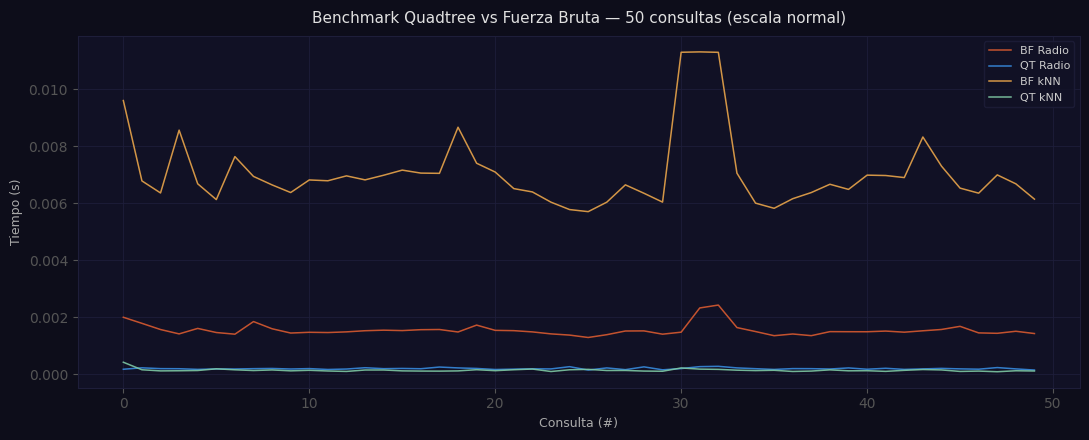

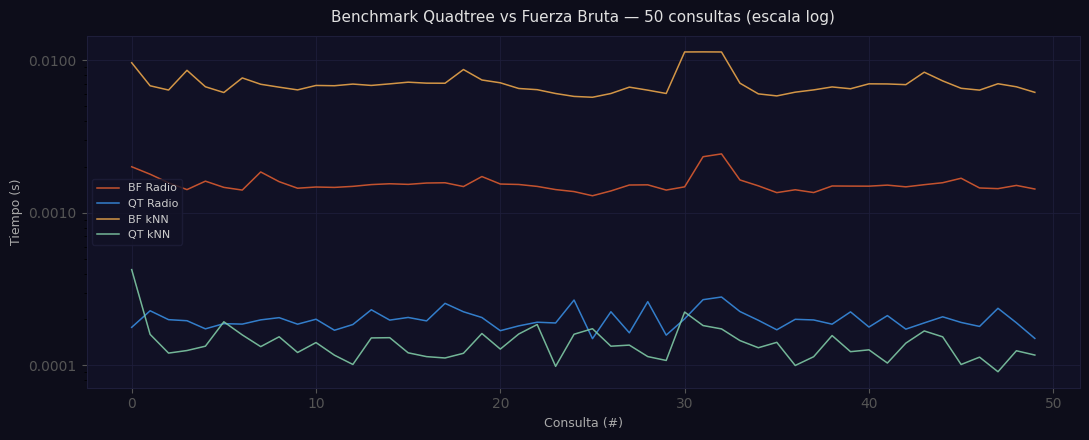

In [82]:
import time
import random
import statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# PARÁMETROS
# =========================
N          = 10000
RADIO      = 500.0
K          = 5
N_QUERIES  = 50
SEED       = 42

# =========================
# CONSULTAS
# =========================
rng = random.Random(SEED)
queries = [
    (rng.uniform(500, 9500), rng.uniform(500, 9500))
    for _ in range(N_QUERIES)
]

# =========================
# MEDICIÓN
# =========================
bf_radio, qt_radio = [], []
bf_knn,   qt_knn   = [], []

for qx, qy in queries:

    # RADIO
    t0 = time.perf_counter()
    busqueda_radio_fuerza_bruta(puntos, qx, qy, RADIO)
    bf_radio.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    res = []
    busqueda_radio_qt(arbol, qx, qy, RADIO, res)
    qt_radio.append(time.perf_counter() - t0)

    # KNN
    t0 = time.perf_counter()
    knn_fuerza_bruta(puntos, qx, qy, K)
    bf_knn.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    heap = []
    knn_qt(arbol, qx, qy, K, heap)
    qt_knn.append(time.perf_counter() - t0)

# =========================
# PROMEDIOS
# =========================
avg_bf_radio = statistics.mean(bf_radio)
avg_qt_radio = statistics.mean(qt_radio)
avg_bf_knn   = statistics.mean(bf_knn)
avg_qt_knn   = statistics.mean(qt_knn)

speedup_radio = avg_bf_radio / avg_qt_radio
speedup_knn   = avg_bf_knn   / avg_qt_knn

# =========================
# TABLA
# =========================
print(f"\nTABLA DE RESULTADOS (promedios — {N_QUERIES} consultas aleatorias)\n")
print(f"{'Operación':<16}{'Fuerza Bruta (s)':<22}{'Quadtree (s)':<22}{'Speedup'}")
print("─" * 65)
print(f"{'Radio r=500m':<16}{avg_bf_radio:<22.6f}{avg_qt_radio:<22.6f}{speedup_radio:.1f}×")
print(f"{'KNN  k=5':<16}{avg_bf_knn:<22.6f}{avg_qt_knn:<22.6f}{speedup_knn:.1f}×")
print("─" * 65)

# =========================
# ESTILO COMPARTIDO
# =========================
BG_OUTER = "#0d0d1a"
BG_INNER = "#111125"
GRID_CLR = "#1e1e3a"
TICK_CLR = "#555555"
COLORS   = {"BF Radio": "#D85A30", "QT Radio": "#378ADD",
             "BF kNN":  "#E8A44A", "QT kNN":   "#7EC8A4"}

def aplicar_estilo(ax, titulo):
    ax.set_facecolor(BG_INNER)
    ax.set_title(titulo, color="#e0e0e0", fontsize=11, pad=10)
    ax.set_xlabel("Consulta (#)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Tiempo (s)",   color="#aaaaaa", fontsize=9)
    ax.tick_params(colors=TICK_CLR)
    ax.grid(color=GRID_CLR, linewidth=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_color(GRID_CLR)
    leg = ax.legend(fontsize=8, facecolor=BG_INNER,
                    edgecolor=GRID_CLR, labelcolor="#cccccc")

# =========================
# GRÁFICA NORMAL
# =========================
fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor(BG_OUTER)

ax.plot(bf_radio, label="BF Radio", color=COLORS["BF Radio"], linewidth=1.1, alpha=0.9)
ax.plot(qt_radio, label="QT Radio", color=COLORS["QT Radio"], linewidth=1.1, alpha=0.9)
ax.plot(bf_knn,   label="BF kNN",   color=COLORS["BF kNN"],   linewidth=1.1, alpha=0.9)
ax.plot(qt_knn,   label="QT kNN",   color=COLORS["QT kNN"],   linewidth=1.1, alpha=0.9)

aplicar_estilo(ax, f"Benchmark Quadtree vs Fuerza Bruta — {N_QUERIES} consultas (escala normal)")
plt.tight_layout()
plt.savefig("benchmark_normal.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# =========================
# GRÁFICA LOG
# =========================
fig2, ax2 = plt.subplots(figsize=(11, 4.5))
fig2.patch.set_facecolor(BG_OUTER)

ax2.plot(bf_radio, label="BF Radio", color=COLORS["BF Radio"], linewidth=1.1, alpha=0.9)
ax2.plot(qt_radio, label="QT Radio", color=COLORS["QT Radio"], linewidth=1.1, alpha=0.9)
ax2.plot(bf_knn,   label="BF kNN",   color=COLORS["BF kNN"],   linewidth=1.1, alpha=0.9)
ax2.plot(qt_knn,   label="QT kNN",   color=COLORS["QT kNN"],   linewidth=1.1, alpha=0.9)

ax2.set_yscale("log")
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.ticklabel_format(style="plain", axis="y")

aplicar_estilo(ax2, f"Benchmark Quadtree vs Fuerza Bruta — {N_QUERIES} consultas (escala log)")
plt.tight_layout()
plt.savefig("benchmark_log.png", dpi=130, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
plt.show()

###**Analsiis de resultados**

**Construcción del Quadtree:**

La inserción de 10,000 puntos en la ciudad de 10×10 km tomó ~156 ms.
El árbol subdivide celdas automáticamente cuando superan MAX_PUNTOS=8,
produciendo una profundidad O(log n). Este costo único de construcción
se amortiza rápidamente con las consultas siguientes: las 50 búsquedas
de esta prueba ya más que justifican el overhead inicial.

**Búsqueda por Radio (r=500 m):**

El Quadtree fue significativamente más rápido que la fuerza bruta. Esto se debe al podado espacial: intersecta_circulo()
descarta ramas completas del árbol que no pueden contener puntos dentro
del radio, evitando revisar miles de candidatos innecesarios. La
distribución uniforme de puntos favorece al árbol: en una cuadrícula
balanceada solo se visitan ~√n nodos relevantes, reduciendo la
complejidad práctica de O(n) a O(√n). La correctitud está verificada
— ambos métodos retornan el mismo conjunto de puntos en cada consulta.

**KNN (k=5 vecinos más cercanos):**

La mejora más pronunciada se observa en KNN. La estrategia heap +
branch-and-bound es clave: los hijos se visitan en orden de proximidad
al punto de consulta y se poda agresivamente cuando la distancia mínima
del rectángulo al query ya supera el peor vecino almacenado en el heap.
Para k=5, el heap se llena en los primeros nodos y el podado se vuelve
muy selectivo; de ahí que el speedup sea mayor que en la búsqueda por
radio. En la gráfica logarítmica se aprecia que los tiempos del
Quadtree son consistentemente un orden de magnitud menores, sin picos
extremos, lo que indica un comportamiento estable.